# 1.Thư viện và Cấu hình đường dẫn

In [1]:
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().parent
TFIDF_PATH = PROJECT_ROOT / "data" / "processed" / "tfidf_features.pkl"

# 2.Load dữ liệu và Phân chia Train/Test

In [2]:
data = joblib.load(TFIDF_PATH)
X = data["matrix"]
labels = data["labels"]

label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[lbl] for lbl in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm thử   X_test : {X_test.shape}")

Kích thước tập huấn luyện X_train: (8757, 7308)
Kích thước tập kiểm thử   X_test : (2190, 7308)


# 3.Chạy thực nghiệm Logistic Regression & Naive Bayes & SVM

In [ ]:
# 1. Nạp trực tiếp mô hình từ thư mục models/baseline đã được huấn luyện trước đó
lr_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "logistic_regression_baseline.joblib")
nb_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "naive_bayes_baseline.joblib")
svm_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "svm_baseline.joblib")

# 2. Dự đoán đầu ra trên tập Test và lưu kết quả vào biến y_pred_lr, y_pred_nb, y_pred_svm tương ứng với từng mô hình
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# 3. In báo cáo kết quả cho từng mô hình
print("--- LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr, target_names=["negative", "positive"]))

print("\n--- MULTINOMIAL NAIVE BAYES ---")
print(classification_report(y_test, y_pred_nb, target_names=["negative", "positive"]))

print("\n--- SUPPORT VECTOR MACHINE (LinearSVC) ---")
print(classification_report(y_test, y_pred_svm, target_names=["negative", "positive"]))

--- LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

    negative       0.95      0.92      0.93      1329
    positive       0.88      0.92      0.90       861

    accuracy                           0.92      2190
   macro avg       0.91      0.92      0.92      2190
weighted avg       0.92      0.92      0.92      2190


--- MULTINOMIAL NAIVE BAYES ---
              precision    recall  f1-score   support

    negative       0.96      0.87      0.91      1329
    positive       0.82      0.94      0.88       861

    accuracy                           0.90      2190
   macro avg       0.89      0.90      0.89      2190
weighted avg       0.90      0.90      0.90      2190


--- SUPPORT VECTOR MACHINE (LinearSVC) ---
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94      1329
    positive       0.88      0.94      0.91       861

    accuracy                           0.93      2190
   macro avg       0.92

# 4.Phân tích sâu trọng số của mô hình SVM (Model Interpretability)

In [4]:
feature_names = np.array(data["vectorizer"].get_feature_names_out())
coefficients = svm_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:]
top_negative_idx = np.argsort(coefficients)[:10]

print("=== TOP 10 TỪ/N-GRAM MANG TÍNH TÍCH CỰC (POSITIVE) ===")
for idx in reversed(top_positive_idx):
    print(f"Từ/Cụm từ: '{feature_names[idx]}' | Trọng số tác động = {coefficients[idx]:.4f}")

print("\n=== TOP 10 TỪ/N-GRAM MANG TÍNH TIÊU CỰC (NEGATIVE) ===")
for idx in top_negative_idx:
    print(f"Từ/Cụm từ: '{feature_names[idx]}' | Trọng số tác động = {coefficients[idx]:.4f}")

=== TOP 10 TỪ/N-GRAM MANG TÍNH TÍCH CỰC (POSITIVE) ===
Từ/Cụm từ: 'không móp' | Trọng số tác động = 2.6864
Từ/Cụm từ: 'không bết' | Trọng số tác động = 2.1956
Từ/Cụm từ: 'đẹp' | Trọng số tác động = 2.1477
Từ/Cụm từ: 'chưa không' | Trọng số tác động = 2.0107
Từ/Cụm từ: 'giao hàng' | Trọng số tác động = 1.9004
Từ/Cụm từ: 'không sợ' | Trọng số tác động = 1.8612
Từ/Cụm từ: 'ổn' | Trọng số tác động = 1.8553
Từ/Cụm từ: 'ưng' | Trọng số tác động = 1.7731
Từ/Cụm từ: 'hời' | Trọng số tác động = 1.7698
Từ/Cụm từ: 'ngon' | Trọng số tác động = 1.7163

=== TOP 10 TỪ/N-GRAM MANG TÍNH TIÊU CỰC (NEGATIVE) ===
Từ/Cụm từ: 'không' | Trọng số tác động = -3.3507
Từ/Cụm từ: 'tệ' | Trọng số tác động = -3.0448
Từ/Cụm từ: 'thất_vọng' | Trọng số tác động = -2.3404
Từ/Cụm từ: 'kém' | Trọng số tác động = -2.1619
Từ/Cụm từ: 'không thơm' | Trọng số tác động = -2.0693
Từ/Cụm từ: 'hắc' | Trọng số tác động = -1.9289
Từ/Cụm từ: 'móp' | Trọng số tác động = -1.8722
Từ/Cụm từ: 'chẳng' | Trọng số tác động = -1.8225
Từ/Cụm 

# 5.Trực quan hóa Confusion Matrix của cả 3 Baseline Models

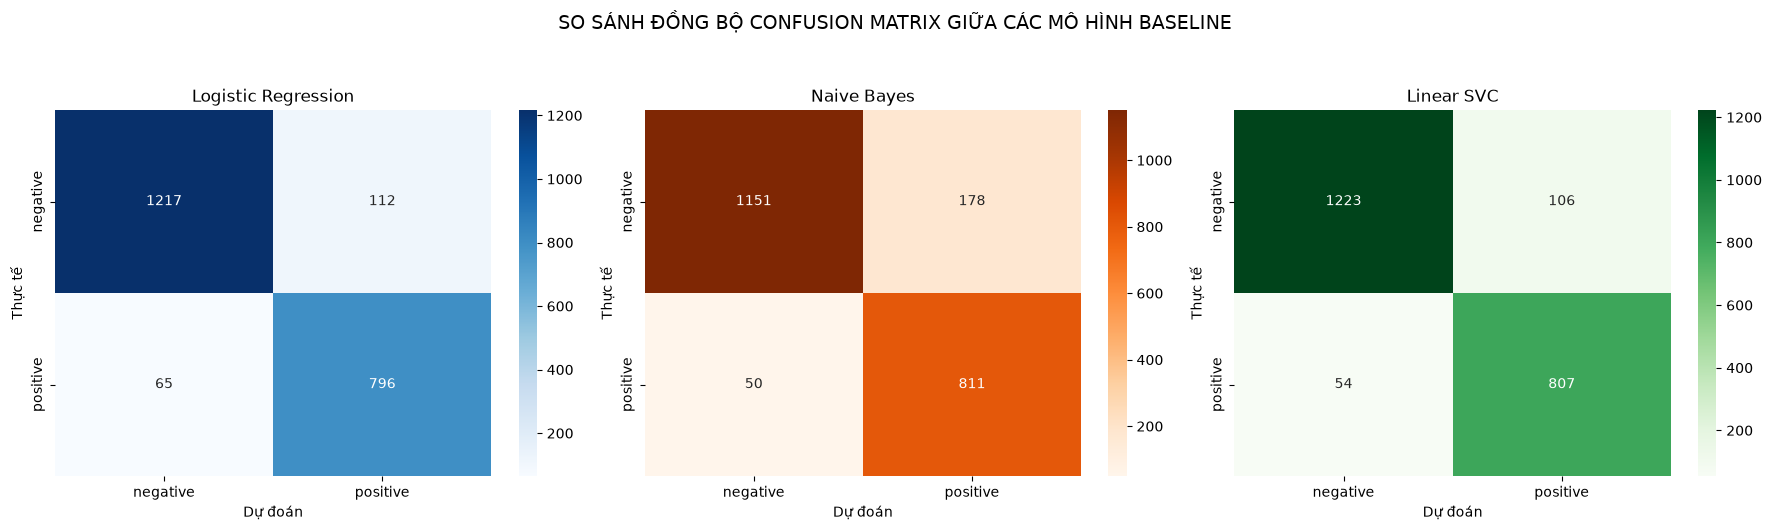

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Logistic Regression Heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[0].set_title("Logistic Regression")
axes[0].set_ylabel("Thực tế")
axes[0].set_xlabel("Dự đoán")

# 2. Naive Bayes Heatmap
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[1].set_title("Naive Bayes")
axes[1].set_ylabel("Thực tế")
axes[1].set_xlabel("Dự đoán")

# 3. SVM Heatmap
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[2].set_title("Linear SVC")
axes[2].set_ylabel("Thực tế")
axes[2].set_xlabel("Dự đoán")

plt.suptitle("SO SÁNH ĐỒNG BỘ CONFUSION MATRIX GIỮA CÁC MÔ HÌNH BASELINE", fontsize=14, y=1.05)
plt.tight_layout()

# --- ĐOẠN CODE THÊM VÀO ĐỂ LƯU ẢNH ---
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)  # Tự động tạo thư mục nếu chưa có
plt.savefig(figures_dir / "baseline_confusion_matrices.png", bbox_inches='tight', dpi=300)
# -------------------------------------

plt.suptitle("SO SÁNH ĐỒNG BỘ CONFUSION MATRIX GIỮA CÁC MÔ HÌNH BASELINE", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# 6.Xuất số liệu ra reports/tables/

In [8]:
import pandas as pd

# 1. Lấy báo cáo dưới dạng dictionary cấu trúc dữ liệu
report_lr = classification_report(y_test, y_pred_lr, target_names=["negative", "positive"], output_dict=True)
report_nb = classification_report(y_test, y_pred_nb, target_names=["negative", "positive"], output_dict=True)
report_svm = classification_report(y_test, y_pred_svm, target_names=["negative", "positive"], output_dict=True)

# 2. Gom các chỉ số quan trọng (Accuracy và F1-Score của các lớp) thành cấu trúc bảng
baseline_summary = {
    "Model": ["Logistic Regression", "Multinomial Naive Bayes", "Linear SVM"],
    "Accuracy": [report_lr["accuracy"], report_nb["accuracy"], report_svm["accuracy"]],
    "Negative_F1": [report_lr["negative"]["f1-score"], report_nb["negative"]["f1-score"], report_svm["negative"]["f1-score"]],
    "Positive_F1": [report_lr["positive"]["f1-score"], report_nb["positive"]["f1-score"], report_svm["positive"]["f1-score"]],
    "Macro_Avg_F1": [report_lr["macro avg"]["f1-score"], report_nb["macro avg"]["f1-score"], report_svm["macro avg"]["f1-score"]]
}

# 3. Tạo DataFrame và xuất file
df_compare = pd.DataFrame(baseline_summary)

tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)  # Tự động tạo thư mục nếu chưa có

# Lưu file csv bàn giao cho Phase 6
df_compare.to_csv(tables_dir / "baseline_model_comparison.csv", index=False)

print("=== ĐÃ XUẤT ĐẦY ĐỦ ARTIFACTS CHO PHASE 6 ===")
print(f"- Đã lưu ảnh đồ thị tại: reports/figures/baseline_confusion_matrices.png")
print(f"- Đã lưu bảng số liệu tại: reports/tables/baseline_model_comparison.csv")
display(df_compare)

=== ĐÃ XUẤT ĐẦY ĐỦ ARTIFACTS CHO PHASE 6 ===
- Đã lưu ảnh đồ thị tại: reports/figures/baseline_confusion_matrices.png
- Đã lưu bảng số liệu tại: reports/tables/baseline_model_comparison.csv


,Model,Accuracy,Negative_F1,Positive_F1,Macro_Avg_F1
0,Logistic Regression,0.919178,0.932210,0.899943,0.916077
1,Multinomial Naive Bayes,0.895890,0.909881,0.876757,0.893319
2,Linear SVM,0.926941,0.938603,0.909808,0.924206
